## 네이버 블로그 광고 글 탐지 프로젝트 (최종 버전)

**목표**  
- 네이버 블로그에서 특정 키워드(예: 헤드셋, 비타민 등) 관련 글을 수집하고,  
- 제목/요약에 포함된 **광고/비광고 키워드**를 기반으로 약한 정답(weak label)을 만든 뒤,  
- 텍스트마이닝 기법(TF-IDF + 로지스틱 회귀)을 이용해  
  - **광고성 글을 잘 잡는 모델**과  
  - **비광고성(실사용) 글을 잘 보여주는 모델**을 비교/개선한다.
---

## 노트북 구성 

1. **환경 설정 & NAVER API 준비**
2. **프로젝트 주제 / 검색어 / 규칙 키워드 정의**
3. **데이터 수집**: 네이버 블로그 API에서 **원본(raw) 텍스트만** 가져오기  
4. **전처리**  
   - 4-1. 정규표현식 기반 클리닝(`clean_text`)  
   - 4-2. Kiwi 형태소 분석 기반 토큰화(`token_text`)  
   - 4-3. 전처리된 텍스트로 규칙 기반 점수 & 라벨링(광고 / 비광고 / 중립)
5. **EDA**: 제목 길이 vs 광고 여부 상관관계, 라벨 분포 시각화
6. **모델 A – Baseline**: 전체 weak label + TF-IDF(text_clean 기반)
7. **모델 B – Strong Sample**: 점수 상·하위 30% 강한 샘플만 사용
8. **모델 C – Kiwi 토큰 Baseline**: Kiwi 토큰(`token_text`) 기반 TF-IDF
9. **사람 라벨(human label) 평가 & Mixed 모델 아이디어**

---
## 최종출력
- 최종출력 결과 Query는 코드 하단부에 [Query 바꿔서 Mixed 평가] 부분 입력 기준입니다.

## 1. 환경 설정 & 기본 import

In [1]:
from dotenv import load_dotenv
import os
import time
import re

import requests
import pandas as pd
import numpy as np

from IPython.display import display

# 시각화
import matplotlib.pyplot as plt
from matplotlib import font_manager, rc

# 한글 폰트 설정 (Windows 기준: 맑은 고딕)
font_path = "C:/Windows/Fonts/malgun.ttf"
if os.path.exists(font_path):
    font_name = font_manager.FontProperties(fname=font_path).get_name()
    rc("font", family=font_name)
    plt.rcParams["axes.unicode_minus"] = False
    print(f"한글 폰트 설정 완료: {font_name}")
else:
    print("⚠ 'C:/Windows/Fonts/malgun.ttf'를 찾을 수 없습니다. 한글 그래프가 깨질 수 있습니다.")

load_dotenv()
CID = os.getenv("NAVER_CLIENT_ID")
CSECRET = os.getenv("NAVER_CLIENT_SECRET")

if CID is None or CSECRET is None:
    raise ValueError(".env에 NAVER_CLIENT_ID / NAVER_CLIENT_SECRET가 설정되어 있지 않습니다.")

HEADERS = {
    "X-Naver-Client-Id": CID,
    "X-Naver-Client-Secret": CSECRET,
    "User-Agent": "Mozilla/5.0",
}

print("NAVER_CLIENT_ID:", CID[:3] + "***" if CID else None)


한글 폰트 설정 완료: Malgun Gothic
NAVER_CLIENT_ID: Dzf***


## 2. 프로젝트 주제 & 검색어 / 규칙 기반 키워드

In [2]:
# 광고가 많이 붙을 법한 검색어들
queries = [
    "헤드셋",
    "헤드셋 추천", "헤드셋 리뷰", "헤드셋 후기", "헤드셋 협찬"
]

MAX_RESULTS_PER_QUERY = 1000  # 검색어당 최대 수집 개수

print("사용할 검색어 목록:", queries)


사용할 검색어 목록: ['헤드셋', '헤드셋 추천', '헤드셋 리뷰', '헤드셋 후기', '헤드셋 협찬']


## 키워드별 가중치 부여

In [3]:
KEYWORDS_BY_SCORE = {
    # 비광고(+) 키워드
    3.0: ["내돈내산"],
    2.5: ["직접 구매", "직접구매"],
    2.0: ["실사용", "솔직 후기", "솔직후기"],
    1.5: ["장단점", "사용 후기", "사용후기", "사용기"],
    1.0: ["직접", "써봤", "경험", "단점", "아쉬운"],
    0.5: ["한달", "진짜", "리얼"],

    # 광고(-) 키워드
    -4.0: ["유료광고", "유료 광고","할인코드","할인 코드",],
    -3.5: ["광고포함", "광고 포함","링크","제휴링크"],
    -3.0: ["협찬", "원고료", "[광고]", "(광고)", "AD", "ad"],
    -2.5: ["제공받아", "제품을 제공받아", "제공을 받아", "제공 받아", "제품제공", "쿠폰코드"],
    -2.0: ["체험단", "서포터즈", "파트너", "공식파트너" "리뷰어로 선정"],
}

# 위 정의를 풀어서 keyword_weights 딕셔너리로 생성
keyword_weights = {
    keyword: score
    for score, keywords in KEYWORDS_BY_SCORE.items()
    for keyword in keywords
}


def score_text(text: str, weights=keyword_weights):
    """키워드 가중치 기반 점수 계산 + 기여도 detail 반환"""
    if not text:
        return 0.0, {}
    total = 0.0
    detail = {}
    for word, w in weights.items():
        count = text.count(word)
        if count > 0:
            contrib = count * w
            total += contrib
            detail[word] = {
                "count": count,
                "weight": w,
                "contrib": contrib,
            }
    return total, detail

def summarize_detail_positive(detail: dict, top_n: int = 3) -> str:
    if not detail:
        return ""
    items = [(w, info) for w, info in detail.items() if info["contrib"] > 0]
    if not items:
        return ""
    items = sorted(items, key=lambda x: x[1]["contrib"], reverse=True)[:top_n]
    return ", ".join(f"{w}(+{info['contrib']:.1f})" for w, info in items)

def summarize_detail_negative(detail: dict, top_n: int = 3) -> str:
    if not detail:
        return ""
    items = [(w, info) for w, info in detail.items() if info["contrib"] < 0]
    if not items:
        return ""
    items = sorted(items, key=lambda x: abs(x[1]["contrib"]), reverse=True)[:top_n]
    return ", ".join(f"{w}({info['contrib']:.1f})" for w, info in items)


## 3. 데이터 수집 

- 네이버 검색 API(blog.json)를 사용해 **원본(raw) 제목/요약 텍스트만** 수집합니다.



In [4]:
def fetch_naver_blogs(query: str, max_results: int = 200, sleep: float = 0.1):
    """네이버 블로그 검색 API(blog.json) 호출"""
    print(f"\n[검색어: {query}] 최대 {max_results}개까지 수집 시도...")
    collected = []
    start = 1

    while len(collected) < max_results and start <= 1000:
        display_n = min(100, max_results - len(collected))
        params = {
            "query": query,
            "display": display_n,
            "start": start,
            "sort": "sim",
        }
        resp = requests.get(
            "https://openapi.naver.com/v1/search/blog.json",
            headers=HEADERS,
            params=params,
        )
        if resp.status_code != 200:
            print(f"  ❌ API 오류 (status={resp.status_code}) → 중단")
            break
        items = resp.json().get("items", [])
        if not items:
            print("  더 이상 가져올 결과가 없습니다.")
            break
        collected.extend(items)
        print(f"  현재까지 수집: {len(collected)}개")
        start += display_n
        time.sleep(sleep)
    return collected


In [5]:
all_rows = []

for q in queries:
    items = fetch_naver_blogs(q, max_results=MAX_RESULTS_PER_QUERY, sleep=0.3)
    for i, item in enumerate(items, start=1):
        raw_title = item["title"]          # HTML 엔티티, <b> 태그 그대로 포함
        raw_desc  = item["description"]    # 마찬가지로 원본 그대로
        link = item["link"]

        all_rows.append({
            "검색어": q,
            "번호": i,
            "제목": raw_title,
            "요약": raw_desc,
            "링크": link,
        })

df_result = pd.DataFrame(all_rows)
df_result = df_result.drop_duplicates(subset=["링크"]).reset_index(drop=True)
df_result["번호"] = df_result.index + 1

print("=== 수집된 원본(raw) 데이터 예시 ===")
display(df_result[["번호", "검색어", "제목", "요약"]].head(10))



[검색어: 헤드셋] 최대 1000개까지 수집 시도...
  현재까지 수집: 100개
  현재까지 수집: 200개
  현재까지 수집: 300개
  현재까지 수집: 400개
  현재까지 수집: 500개
  현재까지 수집: 600개
  현재까지 수집: 700개
  현재까지 수집: 800개
  현재까지 수집: 900개
  현재까지 수집: 1000개

[검색어: 헤드셋 추천] 최대 1000개까지 수집 시도...
  현재까지 수집: 100개
  현재까지 수집: 200개
  현재까지 수집: 300개
  현재까지 수집: 400개
  현재까지 수집: 500개
  현재까지 수집: 600개
  현재까지 수집: 700개
  현재까지 수집: 800개
  현재까지 수집: 900개
  현재까지 수집: 1000개

[검색어: 헤드셋 리뷰] 최대 1000개까지 수집 시도...
  현재까지 수집: 100개
  현재까지 수집: 200개
  현재까지 수집: 300개
  현재까지 수집: 400개
  현재까지 수집: 500개
  현재까지 수집: 600개
  현재까지 수집: 700개
  현재까지 수집: 800개
  현재까지 수집: 900개
  현재까지 수집: 1000개

[검색어: 헤드셋 후기] 최대 1000개까지 수집 시도...
  현재까지 수집: 100개
  현재까지 수집: 200개
  현재까지 수집: 300개
  현재까지 수집: 400개
  현재까지 수집: 500개
  현재까지 수집: 600개
  현재까지 수집: 700개
  현재까지 수집: 800개
  현재까지 수집: 900개
  현재까지 수집: 1000개

[검색어: 헤드셋 협찬] 최대 1000개까지 수집 시도...
  현재까지 수집: 100개
  현재까지 수집: 200개
  현재까지 수집: 300개
  현재까지 수집: 400개
  현재까지 수집: 500개
  현재까지 수집: 600개
  현재까지 수집: 700개
  현재까지 수집: 800개
  현재까지 수집: 900개
  현재까지 수집: 1000개
=== 수집된 원본(raw) 데이터 예시 

,번호,검색어,제목,요약
0,1,헤드셋,가성비 블루투스 <b>헤드셋</b> 노이즈 캔슬링 무선 <b>헤드셋</b> 수디오...,가성비 블루투스 <b>헤드셋</b> 노이즈 캔슬링 무선 <b>헤드셋</b> 수디오 ...
1,2,헤드셋,가성비 헬스 블루투스 <b>헤드셋</b> 추천 QCY H3 PRO 후기,가성비 헬스 블루투스 <b>헤드셋</b> 추천 QCY H3 PRO 후기 가성비 헬스...
2,3,헤드셋,게이밍 <b>헤드셋</b> 로지텍 A50 X 추천하는 이유,그래서 게이밍 <b>헤드셋</b>을 사용하는 분들이 많습니다. 저는 로지텍 A50 ...
3,4,헤드셋,보스 QC 울트라 2세대 <b>헤드셋</b> 무선 블루투스 헤드폰 추천,보스 QC 울트라 2세대 <b>헤드셋</b> 무선 블루투스 헤드폰 추천 안녕하세요....
4,5,헤드셋,소니 <b>헤드셋</b> WH-1000XM5 장점 단점 후기 할인구매,오늘은 제가 직접 사용해본 소니 <b>헤드셋</b> WH-1000XM5 후기와 할인...
5,6,헤드셋,"무선 게이밍<b>헤드셋</b>, 아크티스 노바3 가볍고 만족스러운 성능!",게이밍<b>헤드셋</b> 입니다. 사운드는 게임을 플레이할 때 적의 위치를 확인할 ...
6,7,헤드셋,가성비가 되어버린 블루투스 <b>헤드셋</b> 보스 QC45 중고 추천,가성비가 되어버린 블루투스 <b>헤드셋</b> 보스 QC45 중고 추천 겨울이 다가...
7,8,헤드셋,JBL JR470NC 어린이<b>헤드셋</b> 장점 후기 및 32%할인 구매 방법,그렇다고 아예 <b>헤드셋</b>을 안 쓰게 할 수도 없고요. 그래서 요즘 부모님들...
8,9,헤드셋,마샬 <b>헤드셋</b> 메이저5 소비코 정품 이런 기준으로 선택하세요,"&quot;이 포스팅은 네이버 쇼핑 커넥트 활동의 일환으로, 판매 발생 시 수수료를..."
9,10,헤드셋,게이밍 <b>헤드셋</b> 로지텍 A50 X pc 연결 및 후기,게이밍 <b>헤드셋</b>은 디자인에서부터 착용감 그리고 기능까지 잘 갖추고 있어서...


## 4. 전처리 – 제목/요약 클리닝 및 통합 텍스트 생성


In [6]:
# =========================================
# 4. 전처리: 제목/요약 텍스트 클리닝
#  - HTML 엔티티(&quot;) 복원
#  - 태그(<b> 등) 제거
#  - URL, 특수문자 제거
#  - 공백 정규화
# =========================================
import re
import html

def clean_text(text: str) -> str:
    if pd.isna(text):
        return ""
    text = str(text)

    # (1) HTML 엔티티 복원 (&quot; -> ", &amp; -> &, ...)
    text = html.unescape(text)

    # (2) HTML 태그 제거 (<b>...</b>, <br> 등)
    text = re.sub(r"<[^>]+>", " ", text)

    # (3) URL 제거
    text = re.sub(r"http\S+", " ", text)

    # (4) 한글/영어/숫자/공백만 남기고 나머지 제거
    text = re.sub(r"[^0-9A-Za-z가-힣\s]", " ", text)

    # (5) 혹시 남아 있는 'quot' 같은 찌꺼기 제거 (안전장치)
    text = re.sub(r"\bquot\b", " ", text)

    # (6) 공백 정규화
    text = re.sub(r"\s+", " ", text).strip()

    return text

# 제목/요약 정제
df_result["제목_정제"] = df_result["제목"].apply(clean_text)
df_result["요약_정제"] = df_result["요약"].apply(clean_text)

# 하나의 입력 텍스트로 합치기 (제목 + 요약)
df_result["text_clean"] = df_result["제목_정제"] + " " + df_result["요약_정제"]

df_result[["번호", "제목", "제목_정제", "요약", "요약_정제"]].head()


,번호,제목,제목_정제,요약,요약_정제
0,1,가성비 블루투스 <b>헤드셋</b> 노이즈 캔슬링 무선 <b>헤드셋</b> 수디오...,가성비 블루투스 헤드셋 노이즈 캔슬링 무선 헤드셋 수디오,가성비 블루투스 <b>헤드셋</b> 노이즈 캔슬링 무선 <b>헤드셋</b> 수디오 ...,가성비 블루투스 헤드셋 노이즈 캔슬링 무선 헤드셋 수디오 k2 pro 가성비 블루투...
1,2,가성비 헬스 블루투스 <b>헤드셋</b> 추천 QCY H3 PRO 후기,가성비 헬스 블루투스 헤드셋 추천 QCY H3 PRO 후기,가성비 헬스 블루투스 <b>헤드셋</b> 추천 QCY H3 PRO 후기 가성비 헬스...,가성비 헬스 블루투스 헤드셋 추천 QCY H3 PRO 후기 가성비 헬스 블루투스 헤...
2,3,게이밍 <b>헤드셋</b> 로지텍 A50 X 추천하는 이유,게이밍 헤드셋 로지텍 A50 X 추천하는 이유,그래서 게이밍 <b>헤드셋</b>을 사용하는 분들이 많습니다. 저는 로지텍 A50 ...,그래서 게이밍 헤드셋 을 사용하는 분들이 많습니다 저는 로지텍 A50 X 게이밍 헤...
3,4,보스 QC 울트라 2세대 <b>헤드셋</b> 무선 블루투스 헤드폰 추천,보스 QC 울트라 2세대 헤드셋 무선 블루투스 헤드폰 추천,보스 QC 울트라 2세대 <b>헤드셋</b> 무선 블루투스 헤드폰 추천 안녕하세요....,보스 QC 울트라 2세대 헤드셋 무선 블루투스 헤드폰 추천 안녕하세요 아전입니다 계...
4,5,소니 <b>헤드셋</b> WH-1000XM5 장점 단점 후기 할인구매,소니 헤드셋 WH 1000XM5 장점 단점 후기 할인구매,오늘은 제가 직접 사용해본 소니 <b>헤드셋</b> WH-1000XM5 후기와 할인...,오늘은 제가 직접 사용해본 소니 헤드셋 WH 1000XM5 후기와 할인 구매 팁을 ...


In [7]:
# 1) 링크 중복 개수
dup = df_result["링크"].duplicated().sum()
print("링크 중복 개수:", dup)

# 2) 중복 제거 적용(권장)
df_result = df_result.drop_duplicates(subset=["링크"], keep="first").reset_index(drop=True)
print("중복 제거 후:", len(df_result))


링크 중복 개수: 0
중복 제거 후: 4317


In [8]:
# =========================================
# 4-2. Kiwi 기반 형태소 토큰화
#  - 명사/동사/형용사 중심 토큰 추출
#  - 도메인 불용어(추천, 후기, 리뷰 등) 제거
# =========================================

# Kiwi 형태소 분석기 로드
# - 과제/발표용으로는 kiwipiepy 설치를 가정하지만,
#   없는 환경에서도 노트북이 완전히 깨지지 않도록 try/except 처리합니다.
try:
    from kiwipiepy import Kiwi
    kiwi = Kiwi()
    KIWI_AVAILABLE = True
    print("Kiwi 로드 완료: 형태소 기반 토큰화를 사용합니다.")
except ImportError:
    kiwi = None
    KIWI_AVAILABLE = False
    print("⚠️ kiwipiepy가 설치되어 있지 않아 Kiwi 형태소 분석을 사용할 수 없습니다.")
    print("   → fallback: 단순 공백 기준 토큰화를 사용합니다.")

DOMAIN_STOPWORDS = {
    "추천", "후기", "리뷰",
    "블로그", "사용기", "체험단", "광고", "협찬"
}

def tokenize_kiwi(text: str):
    """Kiwi가 있으면 형태소 기반 토큰, 없으면 공백 기준 토큰으로 fallback"""
    if pd.isna(text):
        return []

    text = str(text)

    # Kiwi 사용 가능하면 형태소 기반 토큰화
    if KIWI_AVAILABLE and kiwi is not None:
        tokens = []
        for token in kiwi.tokenize(text):
            word = token.form
            pos = token.tag

            # 명사/동사/형용사 위주
            if not (pos.startswith("N") or pos.startswith("V")):
                continue

            # 한 글자 짜리 토큰은 대부분 정보량이 낮으므로 제거
            if len(word) <= 1:
                continue

            # 도메인 불용어 제거
            if word in DOMAIN_STOPWORDS:
                continue

            tokens.append(word)
        return tokens

    # 여기까지 왔다는 것은 Kiwi를 쓸 수 없는 환경 → 단순 공백 기준 토큰화
    return [w for w in text.split() if w]

# Kiwi(또는 fallback) 토큰화 적용
df_result["tokens"] = df_result["text_clean"].apply(tokenize_kiwi)
df_result["token_text"] = df_result["tokens"].apply(lambda toks: " ".join(toks))

df_result[["번호", "text_clean", "tokens", "token_text"]].head()


Kiwi 로드 완료: 형태소 기반 토큰화를 사용합니다.


,번호,text_clean,tokens,token_text
0,1,가성비 블루투스 헤드셋 노이즈 캔슬링 무선 헤드셋 수디오 가성비 블루투스 헤드셋 노...,"[가성비, 블루투스, 헤드셋, 노이즈, 슬링, 무선, 헤드셋, 수디오, 가성비, 블...",가성비 블루투스 헤드셋 노이즈 슬링 무선 헤드셋 수디오 가성비 블루투스 헤드셋 노이...
1,2,가성비 헬스 블루투스 헤드셋 추천 QCY H3 PRO 후기 가성비 헬스 블루투스 헤...,"[가성비, 헬스, 블루투스, 헤드셋, 가성비, 헬스, 블루투스, 헤드셋, 가성비, ...",가성비 헬스 블루투스 헤드셋 가성비 헬스 블루투스 헤드셋 가성비 헬스 블루투스 헤드...
2,3,게이밍 헤드셋 로지텍 A50 X 추천하는 이유 그래서 게이밍 헤드셋 을 사용하는 분...,"[게이밍, 헤드셋, 로지텍, 이유, 게이밍, 헤드셋, 사용, 로지텍, 게이밍, 헤드...",게이밍 헤드셋 로지텍 이유 게이밍 헤드셋 사용 로지텍 게이밍 헤드셋 사용 스포츠 게...
3,4,보스 QC 울트라 2세대 헤드셋 무선 블루투스 헤드폰 추천 보스 QC 울트라 2세대...,"[보스, 울트라, 세대, 헤드셋, 무선, 블루투스, 헤드폰, 보스, 울트라, 세대,...",보스 울트라 세대 헤드셋 무선 블루투스 헤드폰 보스 울트라 세대 헤드셋 무선 블루투...
4,5,소니 헤드셋 WH 1000XM5 장점 단점 후기 할인구매 오늘은 제가 직접 사용해본...,"[소니, 헤드셋, 단점, 할인, 구매, 오늘, 사용, 소니, 헤드셋, 할인, 구매,...",소니 헤드셋 단점 할인 구매 오늘 사용 소니 헤드셋 할인 구매 정리 링크 안쪽 피로...


In [9]:
# =========================================
# 4-3. 규칙 기반 점수 계산 & 라벨링 (전처리된 텍스트 기준)
#  - clean_text()로 전처리된 text_clean을 기반으로 점수/라벨을 계산합니다.
#  - 데이터 흐름: 생 데이터 수집(df_result.제목/요약) → clean_text 전처리 → score_text로 점수/라벨 부여
# =========================================

POS_TH = 2.0
NEG_TH = -1.0

scores = []
labels = []
pos_words_list = []
neg_words_list = []

for text in df_result["text_clean"]:
    score, detail = score_text(text)  # 전처리된 텍스트 기준으로 점수 계산

    # 라벨 결정
    if score >= POS_TH:
        label = "비광고성 글"
    elif score <= NEG_TH:
        label = "광고성 글"
    else:
        label = "중립/정보성 글"

    scores.append(score)
    labels.append(label)
    pos_words_list.append(summarize_detail_positive(detail))
    neg_words_list.append(summarize_detail_negative(detail))

df_result["점수"] = scores
df_result["분류"] = labels
df_result["주요_플러스_단어"] = pos_words_list
df_result["주요_마이너스_단어"] = neg_words_list

print("=== 규칙 기반 라벨 분포 (전처리 텍스트 기준) ===")
print(df_result["분류"].value_counts())

print("\n=== 검색어별 라벨 분포 ===")
display(pd.crosstab(df_result["검색어"], df_result["분류"]))

print("\n=== 예시 10건 (전처리 전/후 + 라벨) ===")
display(
    df_result[[
        "번호", "검색어", "분류", "점수",
        "제목", "제목_정제",
        "요약", "요약_정제"
    ]].head(10)
)


=== 규칙 기반 라벨 분포 (전처리 텍스트 기준) ===
분류
중립/정보성 글    2641
광고성 글       1132
비광고성 글       544
Name: count, dtype: int64

=== 검색어별 라벨 분포 ===


분류,광고성 글,비광고성 글,중립/정보성 글
검색어,,,
헤드셋,28,92,880
헤드셋 리뷰,129,97,707
헤드셋 추천,40,44,540
헤드셋 협찬,883,23,72
헤드셋 후기,52,288,442



=== 예시 10건 (전처리 전/후 + 라벨) ===


,번호,검색어,분류,점수,제목,제목_정제,요약,요약_정제
0,1,헤드셋,중립/정보성 글,0.0,가성비 블루투스 <b>헤드셋</b> 노이즈 캔슬링 무선 <b>헤드셋</b> 수디오...,가성비 블루투스 헤드셋 노이즈 캔슬링 무선 헤드셋 수디오,가성비 블루투스 <b>헤드셋</b> 노이즈 캔슬링 무선 <b>헤드셋</b> 수디오 ...,가성비 블루투스 헤드셋 노이즈 캔슬링 무선 헤드셋 수디오 k2 pro 가성비 블루투...
1,2,헤드셋,중립/정보성 글,0.0,가성비 헬스 블루투스 <b>헤드셋</b> 추천 QCY H3 PRO 후기,가성비 헬스 블루투스 헤드셋 추천 QCY H3 PRO 후기,가성비 헬스 블루투스 <b>헤드셋</b> 추천 QCY H3 PRO 후기 가성비 헬스...,가성비 헬스 블루투스 헤드셋 추천 QCY H3 PRO 후기 가성비 헬스 블루투스 헤...
2,3,헤드셋,중립/정보성 글,0.0,게이밍 <b>헤드셋</b> 로지텍 A50 X 추천하는 이유,게이밍 헤드셋 로지텍 A50 X 추천하는 이유,그래서 게이밍 <b>헤드셋</b>을 사용하는 분들이 많습니다. 저는 로지텍 A50 ...,그래서 게이밍 헤드셋 을 사용하는 분들이 많습니다 저는 로지텍 A50 X 게이밍 헤...
3,4,헤드셋,중립/정보성 글,0.0,보스 QC 울트라 2세대 <b>헤드셋</b> 무선 블루투스 헤드폰 추천,보스 QC 울트라 2세대 헤드셋 무선 블루투스 헤드폰 추천,보스 QC 울트라 2세대 <b>헤드셋</b> 무선 블루투스 헤드폰 추천 안녕하세요....,보스 QC 울트라 2세대 헤드셋 무선 블루투스 헤드폰 추천 안녕하세요 아전입니다 계...
4,5,헤드셋,광고성 글,-1.5,소니 <b>헤드셋</b> WH-1000XM5 장점 단점 후기 할인구매,소니 헤드셋 WH 1000XM5 장점 단점 후기 할인구매,오늘은 제가 직접 사용해본 소니 <b>헤드셋</b> WH-1000XM5 후기와 할인...,오늘은 제가 직접 사용해본 소니 헤드셋 WH 1000XM5 후기와 할인 구매 팁을 ...
5,6,헤드셋,중립/정보성 글,0.0,"무선 게이밍<b>헤드셋</b>, 아크티스 노바3 가볍고 만족스러운 성능!",무선 게이밍 헤드셋 아크티스 노바3 가볍고 만족스러운 성능,게이밍<b>헤드셋</b> 입니다. 사운드는 게임을 플레이할 때 적의 위치를 확인할 ...,게이밍 헤드셋 입니다 사운드는 게임을 플레이할 때 적의 위치를 확인할 때 그리고 몰...
6,7,헤드셋,중립/정보성 글,0.0,가성비가 되어버린 블루투스 <b>헤드셋</b> 보스 QC45 중고 추천,가성비가 되어버린 블루투스 헤드셋 보스 QC45 중고 추천,가성비가 되어버린 블루투스 <b>헤드셋</b> 보스 QC45 중고 추천 겨울이 다가...,가성비가 되어버린 블루투스 헤드셋 보스 QC45 중고 추천 겨울이 다가오며 서랍속에...
7,8,헤드셋,중립/정보성 글,0.0,JBL JR470NC 어린이<b>헤드셋</b> 장점 후기 및 32%할인 구매 방법,JBL JR470NC 어린이 헤드셋 장점 후기 및 32 할인 구매 방법,그렇다고 아예 <b>헤드셋</b>을 안 쓰게 할 수도 없고요. 그래서 요즘 부모님들...,그렇다고 아예 헤드셋 을 안 쓰게 할 수도 없고요 그래서 요즘 부모님들 사이에서 어...
8,9,헤드셋,중립/정보성 글,0.0,마샬 <b>헤드셋</b> 메이저5 소비코 정품 이런 기준으로 선택하세요,마샬 헤드셋 메이저5 소비코 정품 이런 기준으로 선택하세요,"&quot;이 포스팅은 네이버 쇼핑 커넥트 활동의 일환으로, 판매 발생 시 수수료를...",이 포스팅은 네이버 쇼핑 커넥트 활동의 일환으로 판매 발생 시 수수료를 제공받습니다...
9,10,헤드셋,중립/정보성 글,1.0,게이밍 <b>헤드셋</b> 로지텍 A50 X pc 연결 및 후기,게이밍 헤드셋 로지텍 A50 X pc 연결 및 후기,게이밍 <b>헤드셋</b>은 디자인에서부터 착용감 그리고 기능까지 잘 갖추고 있어서...,게이밍 헤드셋 은 디자인에서부터 착용감 그리고 기능까지 잘 갖추고 있어서 게임을 즐...


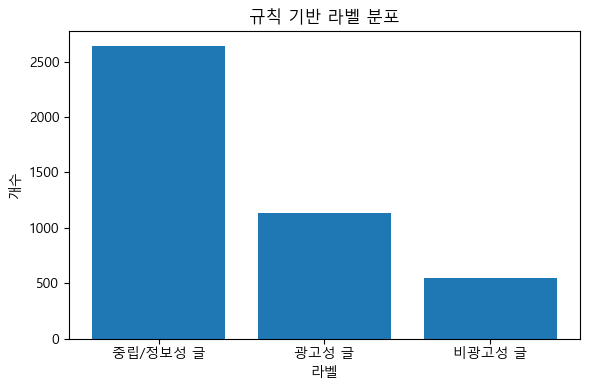

In [10]:
label_counts = df_result["분류"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(label_counts.index, label_counts.values)
plt.title("규칙 기반 라벨 분포")
plt.xlabel("라벨")
plt.ylabel("개수")
plt.tight_layout()
plt.show()


## 5. Baseline 모델 – 전체 weak label 기반 이진 분류

- 규칙 기반 라벨 중 **광고성 글 / 비광고성 글**만 사용하여
  이진 분류용 데이터셋을 구성합니다.
- `text_clean`을 TF-IDF(unigram+bigram)로 벡터화하고,
  로지스틱 회귀(Logistic Regression)로 학습합니다.


In [11]:
# =========================================
# 5-1. 데이터셋 구성 (Baseline용)
#  - 광고 / 비광고만 사용 (중립은 제외)
# =========================================
label_map = {"광고성 글": 0, "비광고성 글": 1}

df_bin = df_result[df_result["분류"].isin(label_map.keys())].copy()
df_bin["y"] = df_bin["분류"].map(label_map)

print("라벨 분포 (0=광고, 1=비광고):")
print(df_bin["y"].value_counts())


라벨 분포 (0=광고, 1=비광고):
y
0    1132
1     544
Name: count, dtype: int64


In [12]:
# =========================================
# 5-2. TF-IDF 벡터화 + Train/Test 분할 + 로지스틱 회귀
# =========================================
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_text = df_bin["text_clean"].tolist()
y = df_bin["y"].values

# unigram + bigram TF-IDF
tfidf_base = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=3
)
X = tfidf_base.fit_transform(X_text)
print("TF-IDF shape (Baseline):", X.shape)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape, "Test size:", X_test.shape)

# 로지스틱 회귀 학습
logit_base = LogisticRegression(
    solver="liblinear",
    max_iter=1000,
    class_weight="balanced"   # 불균형 완화용
)

logit_base.fit(X_train, y_train)

# 예측 확률 (비광고일 확률 = 클래스 1)
import numpy as np
y_proba_base = logit_base.predict_proba(X_test)[:, 1]
y_pred_base = (y_proba_base >= 0.5).astype(int)


TF-IDF shape (Baseline): (1676, 3679)
Train size: (1340, 3679) Test size: (336, 3679)


In [13]:
# train 쪽 y
vals_tr, cnts_tr = np.unique(y_train, return_counts=True)
ratio_tr = pd.Series(cnts_tr, index=vals_tr, name="train_count")
ratio_tr_pct = ratio_tr / ratio_tr.sum() * 100

print("\n=== Train 광고/비광고 분포 ===")
print(ratio_tr)
print("\n(%)")
print(ratio_tr_pct.round(2))

# test 쪽 y
vals_te, cnts_te = np.unique(y_test, return_counts=True)
ratio_te = pd.Series(cnts_te, index=vals_te, name="test_count")
ratio_te_pct = ratio_te / ratio_te.sum() * 100

print("\n=== Test 광고/비광고 분포 ===")
print(ratio_te)
print("\n(%)")
print(ratio_te_pct.round(2))



=== Train 광고/비광고 분포 ===
0    905
1    435
Name: train_count, dtype: int64

(%)
0    67.54
1    32.46
Name: train_count, dtype: float64

=== Test 광고/비광고 분포 ===
0    227
1    109
Name: test_count, dtype: int64

(%)
0    67.56
1    32.44
Name: test_count, dtype: float64


=== Baseline 모델 성능 (threshold=0.5) ===
Accuracy : 0.9285714285714286
Precision: 0.8571428571428571
Recall   : 0.9357798165137615
F1-score : 0.8947368421052632

[Classification Report]
              precision    recall  f1-score   support

          광고       0.97      0.93      0.95       227
         비광고       0.86      0.94      0.89       109

    accuracy                           0.93       336
   macro avg       0.91      0.93      0.92       336
weighted avg       0.93      0.93      0.93       336



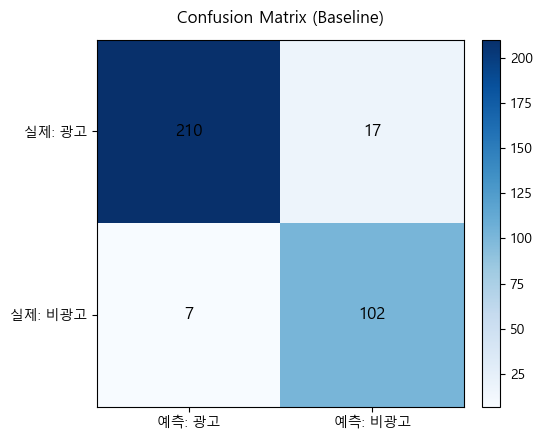

In [14]:
# =========================================
# 5-3. Baseline 모델 평가
# =========================================
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
import pandas as pd  # ← 없으면 추가

print("=== Baseline 모델 성능 (threshold=0.5) ===")
print("Accuracy :", accuracy_score(y_test, y_pred_base))
print("Precision:", precision_score(y_test, y_pred_base))
print("Recall   :", recall_score(y_test, y_pred_base))
print("F1-score :", f1_score(y_test, y_pred_base))

print("\n[Classification Report]")
print(classification_report(y_test, y_pred_base, target_names=["광고", "비광고"]))

# --- 여기부터 Confusion Matrix만 예쁘게 출력 ---
cm_base = confusion_matrix(y_test, y_pred_base)

cm_base_df = pd.DataFrame(
    cm_base,
    index=["실제: 광고", "실제: 비광고"],
    columns=["예측: 광고", "예측: 비광고"],
)

# --- Confusion Matrix 시각화(히트맵) ---
import matplotlib.pyplot as plt
import numpy as np

# cm_base_df는 이미 위에서 만들었으니 그대로 사용 가능

plt.figure(figsize=(5.5, 4.5))
plt.imshow(cm_base_df.values, cmap="Blues")   
plt.title("Confusion Matrix (Baseline)", pad=12)
plt.xticks(np.arange(cm_base_df.shape[1]), cm_base_df.columns, rotation=0)
plt.yticks(np.arange(cm_base_df.shape[0]), cm_base_df.index)

# 셀 안에 숫자 표시
for i in range(cm_base_df.shape[0]):
    for j in range(cm_base_df.shape[1]):
        plt.text(j, i, cm_base_df.values[i, j],
                 ha="center", va="center", fontsize=12)

plt.colorbar(fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


## 6. Strong Sample 모델 – 점수 상·하위 30%만 사용

- 규칙 점수 분포에서 상·하위 30%에 해당하는 문서만 **강한 샘플(strong sample)**로 선택합니다.
- 라벨이 더 확실한 샘플들만 사용해 동일한 구조의 로지스틱 회귀 모델을 학습합니다.


In [15]:
# =========================================
# 6-1. 점수 상·하위 30% 강한 샘플 선택
#  - 0점은 애매한 구간으로 보고 Strong 기준 계산에서 제외
#  - 광고 / 비광고(df_bin)에서만 기준을 잡고, 거기서 바로 Strong 추출
# =========================================

score = df_bin["점수"]

# 0점은 애매한 구간으로 보고, Strong 기준 계산에서는 제외
non_zero = score[score != 0]

q_low  = non_zero.quantile(0.3)   # 하위 30% 기준
q_high = non_zero.quantile(0.7)   # 상위 30% 기준

print("하위 30% 기준(q_low) :", q_low)
print("상위 30% 기준(q_high):", q_high)

# Strong 샘플: 광고/비광고(df_bin) 중에서 점수가 양 극단에 있는 애들만
mask_strong = (score <= q_low) | (score >= q_high)
df_strong = df_bin[mask_strong].copy()

df_strong["y"] = df_strong["분류"].map(label_map)

print("강한 샘플 개수:", len(df_strong))
print("강한 샘플 라벨 분포:")
print(df_strong["y"].value_counts())

df_strong[["번호", "점수", "분류", "y", "제목_정제"]].head()


하위 30% 기준(q_low) : -3.0
상위 30% 기준(q_high): 2.0
강한 샘플 개수: 1421
강한 샘플 라벨 분포:
y
0    877
1    544
Name: count, dtype: int64


,번호,점수,분류,y,제목_정제
23,24,2.0,비광고성 글,1,블루투스 게이밍 헤드셋 후기 로지텍 A50 X
28,29,4.5,비광고성 글,1,소니 헤드셋 추천 WH 1000XM6 실제 사용 후기
35,36,-3.5,광고성 글,0,삼성공식 JBL QUANTUM 350 퀀텀 무선 게이밍 헤드셋
38,39,2.0,비광고성 글,1,게이밍 헤드셋 끝판왕 로지텍G PRO X 2 LIGHTSPEED 실사용
39,40,3.0,비광고성 글,1,게이밍 헤드셋 추천 후기 결국 로지텍 A50 X인 이유


In [16]:
# =========================================
# 6-2. Strong Sample용 TF-IDF + 로지스틱 회귀
# =========================================
X_text_strong = df_strong["text_clean"].tolist()
y_strong = df_strong["y"].values

tfidf_strong = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=3
)
X_strong = tfidf_strong.fit_transform(X_text_strong)
print("TF-IDF shape (Strong):", X_strong.shape)

X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(
    X_strong, y_strong,
    test_size=0.2,
    random_state=42,
    stratify=y_strong
)

print("Strong Train size:", X_tr_s.shape, "Strong Test size:", X_te_s.shape)

logit_strong = LogisticRegression(
    solver="liblinear",
    max_iter=1000,
    class_weight="balanced"
)

logit_strong.fit(X_tr_s, y_tr_s)

y_proba_strong = logit_strong.predict_proba(X_te_s)[:, 1]
y_pred_strong = (y_proba_strong >= 0.5).astype(int)


TF-IDF shape (Strong): (1421, 3125)
Strong Train size: (1136, 3125) Strong Test size: (285, 3125)


=== Strong Sample 모델 성능 (threshold=0.5) ===
Accuracy : 0.9228070175438596
Precision: 0.865546218487395
Recall   : 0.944954128440367
F1-score : 0.9035087719298246

[Classification Report]
              precision    recall  f1-score   support

          광고       0.96      0.91      0.94       176
         비광고       0.87      0.94      0.90       109

    accuracy                           0.92       285
   macro avg       0.91      0.93      0.92       285
weighted avg       0.93      0.92      0.92       285



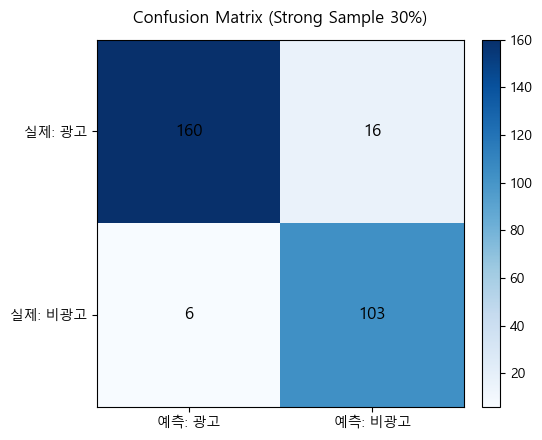

In [17]:
# =========================================
# 6-3. Strong Sample 모델 평가
# =========================================
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
import pandas as pd

print("=== Strong Sample 모델 성능 (threshold=0.5) ===")
print("Accuracy :", accuracy_score(y_te_s, y_pred_strong))
print("Precision:", precision_score(y_te_s, y_pred_strong))
print("Recall   :", recall_score(y_te_s, y_pred_strong))
print("F1-score :", f1_score(y_te_s, y_pred_strong))

print("\n[Classification Report]")
print(classification_report(y_te_s, y_pred_strong, target_names=["광고", "비광고"]))

# ✅ test set 기준 Confusion Matrix (반드시 y_te_s, y_pred_strong 사용)
cm_strong = confusion_matrix(y_te_s, y_pred_strong)

cm_strong_df = pd.DataFrame(
    cm_strong,
    index=["실제: 광고", "실제: 비광고"],
    columns=["예측: 광고", "예측: 비광고"],
)

# --- Confusion Matrix 시각화(히트맵) ---
import matplotlib.pyplot as plt
import numpy as np

# cm_strong_df는 이미 위에서 만들었으니 그대로 사용 가능

plt.figure(figsize=(5.5, 4.5))
plt.imshow(cm_strong_df.values, cmap="Blues")   
plt.title("Confusion Matrix (Strong Sample 30%)", pad=12)
plt.xticks(np.arange(cm_strong_df.shape[1]), cm_strong_df.columns, rotation=0)
plt.yticks(np.arange(cm_strong_df.shape[0]), cm_strong_df.index)

# 셀 안에 숫자 표시
for i in range(cm_strong_df.shape[0]):
    for j in range(cm_strong_df.shape[1]):
        plt.text(j, i, cm_strong_df.values[i, j],
                 ha="center", va="center", fontsize=12)

plt.colorbar(fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()



## Kiwi 토큰 기반 Baseline

- 4-2에서 만든 `token_text`(Kiwi 형태소 토큰 문자열)를 사용해  
  Baseline과 동일한 구조의 TF-IDF + 로지스틱 회귀 모델을 학습합니다.
- 목적:  
  - **단순 클리닝 텍스트(`text_clean`) 기반 Baseline** 과  
  - **Kiwi 형태소 토큰(`token_text`) 기반 Baseline** 의 성능을 비교하는 것.
- Kiwi 라이브러리(`kiwipiepy`)가 설치되어 있지 않은 환경에서는  
  `token_text`가 단순 공백 기준 토큰화로 대체될 수 있습니다(코드 내 주석 참고).


=== Baseline (Kiwi 토큰) 평가 ===
[Classification Report]
              precision    recall  f1-score   support

          광고       0.91      0.92      0.91       227
         비광고       0.82      0.81      0.81       109

    accuracy                           0.88       336
   macro avg       0.87      0.86      0.86       336
weighted avg       0.88      0.88      0.88       336


[Confusion Matrix]


,예측: 광고,예측: 비광고
실제: 광고,208,19
실제: 비광고,21,88


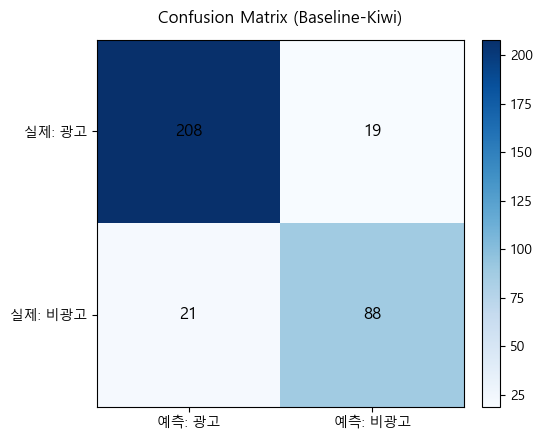

In [18]:
# =========================================
# Baseline-kiwi: Kiwi 토큰 기반 TF-IDF + 로지스틱
# =========================================

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd  

# Kiwi 토큰화 결과가 존재하는지 확인
if "token_text" not in df_result.columns:
    print("⚠️ df_result['token_text']가 없어 Kiwi Baseline을 건너뜁니다.")
else:
    # 광고/비광고만 사용하는 df_bin에 token_text 붙이기
    df_bin["token_text"] = df_result.loc[df_bin.index, "token_text"]

    X_text_kiwi = df_bin["token_text"].tolist()
    y = df_bin["y"].values

    vectorizer_kiwi = TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=3,
        max_df=0.9
    )
    X_kiwi = vectorizer_kiwi.fit_transform(X_text_kiwi)

    X_train_k, X_test_k, y_train_k, y_test_k = train_test_split(
        X_kiwi, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    clf_kiwi = LogisticRegression(
        solver="liblinear",
        max_iter=1000,
        class_weight="balanced"
    )
    clf_kiwi.fit(X_train_k, y_train_k)

    y_pred_k = clf_kiwi.predict(X_test_k)

    print("=== Baseline (Kiwi 토큰) 평가 ===")
    print("[Classification Report]")
    print(classification_report(y_test_k, y_pred_k, target_names=["광고", "비광고"]))

    # ---- 여기서부터 Confusion Matrix 예쁘게 ----
    cm_kiwi = confusion_matrix(y_test_k, y_pred_k)
    cm_kiwi_df = pd.DataFrame(
        cm_kiwi,
        index=["실제: 광고", "실제: 비광고"],
        columns=["예측: 광고", "예측: 비광고"],
    )

    print("\n[Confusion Matrix]")
    display(cm_kiwi_df)

# --- Confusion Matrix 시각화(히트맵) : Kiwi Baseline ---
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(5.5, 4.5))
plt.imshow(cm_kiwi_df.values, cmap="Blues")
plt.title("Confusion Matrix (Baseline-Kiwi)", pad=12)

plt.xticks(np.arange(cm_kiwi_df.shape[1]), cm_kiwi_df.columns, rotation=0)
plt.yticks(np.arange(cm_kiwi_df.shape[0]), cm_kiwi_df.index)

# 셀 안 숫자 표시
for i in range(cm_kiwi_df.shape[0]):
    for j in range(cm_kiwi_df.shape[1]):
        plt.text(j, i, cm_kiwi_df.values[i, j],
                 ha="center", va="center", fontsize=12)

plt.colorbar(fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


## 7. Baseline vs Strong Sample 성능 비교

- 규칙 기반 weak label 전체를 사용한 Baseline 모델과,
  점수 상·하위 30% 강한 샘플만 사용한 모델의 성능을 한 표로 비교합니다.


In [19]:
# =========================================
# 7. Baseline vs Strong Sample 성능 비교표
# =========================================
def get_scores(y_true, y_pred, name):
    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
    }

results = []
results.append(get_scores(y_test, y_pred_base, "Baseline (text_clean)"))
results.append(get_scores(y_te_s, y_pred_strong, "Strong 30% (상·하위 점수)"))

# Kiwi Baseline이 학습/평가되었다면 함께 비교
if "y_pred_k" in globals() and "y_test_k" in globals():
    results.append(get_scores(y_test_k, y_pred_k, "Baseline (Kiwi token_text)"))

df_scores = pd.DataFrame(results)
df_scores[["accuracy", "precision", "recall", "f1"]] = \
    df_scores[["accuracy", "precision", "recall", "f1"]].round(3)

display(df_scores)



,model,accuracy,precision,recall,f1
0,Baseline (text_clean),0.929,0.857,0.936,0.895
1,Strong 30% (상·하위 점수),0.923,0.866,0.945,0.904
2,Baseline (Kiwi token_text),0.881,0.822,0.807,0.815


## 8. 사람 라벨(human label) 기반 평가 & Mixed 모델

- 규칙 기반 weak label로 학습한 Baseline / Strong 30% 모델이
  **사람이 직접 라벨링한 정답(test셋)** 기준으로는 어떻게 성능이 나오는지 확인합니다.
- weak label(규칙 라벨)과 human label이 기준이 다르다는 점을 보여주고,
  weak + human 데이터를 함께 사용하는 Mixed 모델도 추가로 학습합니다.


In [20]:
# =========================================
# 8-1. 사람 라벨 CSV 로드 & df_result와 링크 기준 매칭
# =========================================
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
)

# 라벨 CSV 경로 (필요시 파일명 수정)
label_csv_path = "human_label_ad.csv"

lab = pd.read_csv(label_csv_path)
print("라벨 CSV 컬럼:", lab.columns.tolist())
print("라벨 CSV 행 수:", len(lab))

# 반드시 '링크', 'human_label' 컬럼이 있어야 함
if not {"링크", "human_label"}.issubset(lab.columns):
    raise ValueError("라벨 CSV에는 반드시 '링크', 'human_label' 컬럼이 있어야 합니다.")

lab["human_label"] = lab["human_label"].astype(int)
lab = lab.dropna(subset=["링크"])
lab = lab.drop_duplicates(subset="링크", keep="last")
print("링크 기준 중복 제거 후 라벨 수:", len(lab))

# df_result와 링크 기준으로 merge -> 사람 라벨 test셋(df_eval)
df_eval = pd.merge(
    df_result,
    lab[["링크", "human_label"]],
    on="링크",
    how="inner",
)

print("사람 라벨이 매칭된 test셋 크기:", len(df_eval))
display(df_eval[["제목", "분류", "점수", "human_label"]].head())


# =========================================
# 8-2. 규칙 / Baseline / Strong30 / Mixed 모델 vs 사람 라벨
# =========================================

# (1) 규칙 라벨(분류) -> 0/1로 매핑
rule_map = {
    "광고성 글": 0,
    "비광고성 글": 1,
    "중립/정보성 글": 1,  # 중립을 비광고 쪽으로 보는 버전
}
df_eval["rule_label"] = df_eval["분류"].map(rule_map)

# (2) 텍스트 컬럼 이름 (본 노트북에서는 text_clean 사용)
text_col = "text_clean"

# (3) Baseline / Strong30 모델 예측 (이미 학습된 tfidf_base, logit_base, tfidf_strong, logit_strong 사용)
X_eval_base = tfidf_base.transform(df_eval[text_col].tolist())
proba_eval_base = logit_base.predict_proba(X_eval_base)[:, 1]
pred_eval_base = (proba_eval_base >= 0.5).astype(int)

X_eval_strong = tfidf_strong.transform(df_eval[text_col].tolist())
proba_eval_strong = logit_strong.predict_proba(X_eval_strong)[:, 1]
pred_eval_strong = (proba_eval_strong >= 0.5).astype(int)

# (4) Mixed 모델: weak 데이터 + 사람 라벨 데이터 함께 사용 (sample_weight로 human label을 더 강하게 반영)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# weak 데이터: 광고/비광고만 사용 (중립 제외)
label_map_bin = {"광고성 글": 0, "비광고성 글": 1}
df_weak = df_result[df_result["분류"].isin(label_map_bin.keys())].copy()
df_weak["y"] = df_weak["분류"].map(label_map_bin)
df_weak["w"] = 1.0  # weak label weight

# 사람 라벨 데이터
df_human = df_eval.copy()
df_human["y"] = df_human["human_label"]
df_human["w"] = 10.0  # human label weight (weak보다 훨씬 크게)

# weak + human concat
df_mix = pd.concat(
    [df_weak[[text_col, "y", "w"]], df_human[[text_col, "y", "w"]]],
    ignore_index=True,
)
print("df_mix shape:", df_mix.shape)

tfidf_mix = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=3,
)
X_mix = tfidf_mix.fit_transform(df_mix[text_col].tolist())
y_mix = df_mix["y"].values
w_mix = df_mix["w"].values

logit_mix = LogisticRegression(
    solver="liblinear",
    max_iter=1000,
    class_weight="balanced",
)
logit_mix.fit(X_mix, y_mix, sample_weight=w_mix)
print("Mixed 모델 학습 완료")

# Mixed 모델의 사람 라벨 test셋 성능
X_eval_mix = tfidf_mix.transform(df_eval[text_col].tolist())
proba_eval_mix = logit_mix.predict_proba(X_eval_mix)[:, 1]
pred_eval_mix = (proba_eval_mix >= 0.5).astype(int)


print("\n=== [Baseline 모델] vs [사람 라벨] ===")
print(classification_report(df_eval["human_label"], pred_eval_base, target_names=["광고", "비광고"]))

print("\n=== [Strong 30% 모델] vs [사람 라벨] ===")
print(classification_report(df_eval["human_label"], pred_eval_strong, target_names=["광고", "비광고"]))


# 8-3. 사람 라벨 기준 성능 비교표 (PPT용 요약)
def get_scores_human(y_true, y_pred, name):
    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
    }

rows = []
rows.append(get_scores_human(df_eval["human_label"], pred_eval_base, "Baseline"))
rows.append(get_scores_human(df_eval["human_label"], pred_eval_strong, "Strong 30%"))


df_scores_human = pd.DataFrame(rows)
df_scores_human


라벨 CSV 컬럼: ['링크', 'human_label']
라벨 CSV 행 수: 350
링크 기준 중복 제거 후 라벨 수: 342
사람 라벨이 매칭된 test셋 크기: 304


,제목,분류,점수,human_label
0,소니 <b>헤드셋</b> 추천 WH-1000XM6 실제 사용 후기,비광고성 글,4.5,1
1,유아 <b>헤드셋</b> 구입 미취학 초등 어린이 헤드폰 키즈 얼굴 크기 비교,중립/정보성 글,0.0,0
2,아기 이어머프 청력보호 소음방지 귀마개 <b>헤드셋</b> 프로살림 후기,중립/정보성 글,0.0,0
3,게이밍 <b>헤드셋</b> 경량 설계로 편안한 로지텍 G522 주요 특징은?,중립/정보성 글,0.0,0
4,무선 게이밍<b>헤드셋</b> 추천 자유롭고 가벼운 제닉스 타이탄 WH6,중립/정보성 글,0.0,0


df_mix shape: (1980, 3)
Mixed 모델 학습 완료

=== [Baseline 모델] vs [사람 라벨] ===
              precision    recall  f1-score   support

          광고       0.89      0.72      0.79       216
         비광고       0.53      0.77      0.63        88

    accuracy                           0.73       304
   macro avg       0.71      0.75      0.71       304
weighted avg       0.78      0.73      0.74       304


=== [Strong 30% 모델] vs [사람 라벨] ===
              precision    recall  f1-score   support

          광고       0.91      0.69      0.79       216
         비광고       0.53      0.84      0.65        88

    accuracy                           0.74       304
   macro avg       0.72      0.77      0.72       304
weighted avg       0.80      0.74      0.75       304



,model,accuracy,precision,recall,f1
0,Baseline,0.733553,0.527132,0.772727,0.626728
1,Strong 30%,0.736842,0.528571,0.840909,0.649123


---
## 쿼리바꿔서 mixed평가


In [21]:
# 광고가 많이 붙을 법한 검색어들
queries_q2 = [
    "립밤",
    "립밤 추천", "립밤 리뷰", "립밤 후기", "립밤 협찬",

]

MAX_RESULTS_PER_QUERY_Q2 = 1000  # 검색어당 최대 수집 개수

print("사용할 검색어 목록:", queries_q2)


사용할 검색어 목록: ['립밤', '립밤 추천', '립밤 리뷰', '립밤 후기', '립밤 협찬']


In [22]:
# 광고/비광고 단어 가중치
# =========================================
# 규칙 기반 점수: 키워드별 가중치 정의 (score → 키워드 리스트)
# =========================================

KEYWORDS_BY_SCORE = {
    # 비광고(+) 키워드
    3.0: ["내돈내산"],
    2.5: ["직접 구매", "직접구매"],
    2.0: ["실사용", "솔직 후기", "솔직후기"],
    1.5: ["장단점", "사용 후기", "사용후기", "사용기"],
    1.0: ["직접", "써봤", "경험", "단점", "아쉬운"],
    0.5: ["한달", "진짜", "리얼"],

    # 광고(-) 키워드
    -4.0: ["유료광고", "유료 광고","할인코드","할인 코드",],
    -3.5: ["광고포함", "광고 포함","링크","제휴링크"],
    -3.0: ["협찬", "원고료", "[광고]", "(광고)", "AD", "ad"],
    -2.5: ["제공받아", "제품을 제공받아", "제공을 받아", "제공 받아", "제품제공", "쿠폰코드"],
    -2.0: ["체험단", "서포터즈", "파트너", "공식파트너" "리뷰어로 선정"],
}

# 위 정의를 풀어서 keyword_weights 딕셔너리로 생성
keyword_weights = {
    keyword: score
    for score, keywords in KEYWORDS_BY_SCORE.items()
    for keyword in keywords
}


def score_text(text: str, weights=keyword_weights):
    """키워드 가중치 기반 점수 계산 + 기여도 detail 반환"""
    if not text:
        return 0.0, {}
    total = 0.0
    detail = {}
    for word, w in weights.items():
        count = text.count(word)
        if count > 0:
            contrib = count * w
            total += contrib
            detail[word] = {
                "count": count,
                "weight": w,
                "contrib": contrib,
            }
    return total, detail

def summarize_detail_positive(detail: dict, top_n: int = 3) -> str:
    if not detail:
        return ""
    items = [(w, info) for w, info in detail.items() if info["contrib"] > 0]
    if not items:
        return ""
    items = sorted(items, key=lambda x: x[1]["contrib"], reverse=True)[:top_n]
    return ", ".join(f"{w}(+{info['contrib']:.1f})" for w, info in items)

def summarize_detail_negative(detail: dict, top_n: int = 3) -> str:
    if not detail:
        return ""
    items = [(w, info) for w, info in detail.items() if info["contrib"] < 0]
    if not items:
        return ""
    items = sorted(items, key=lambda x: abs(x[1]["contrib"]), reverse=True)[:top_n]
    return ", ".join(f"{w}({info['contrib']:.1f})" for w, info in items)


In [23]:
def fetch_naver_blogs_q2(query: str, max_results: int = 200, sleep: float = 0.1):
    """네이버 블로그 검색 API(blog.json) 호출"""
    print(f"\n[검색어: {query}] 최대 {max_results}개까지 수집 시도...")
    collected = []
    start = 1

    while len(collected) < max_results and start <= 1000:
        display_n = min(100, max_results - len(collected))
        params = {
            "query": query,
            "display": display_n,
            "start": start,
            "sort": "sim",
        }
        resp = requests.get(
            "https://openapi.naver.com/v1/search/blog.json",
            headers=HEADERS,
            params=params,
        )
        if resp.status_code != 200:
            print(f"  ❌ API 오류 (status={resp.status_code}) → 중단")
            break
        items = resp.json().get("items", [])
        if not items:
            print("  더 이상 가져올 결과가 없습니다.")
            break
        collected.extend(items)
        print(f"  현재까지 수집: {len(collected)}개")
        start += display_n
        time.sleep(sleep)
    return collected


## 데이터 수집 #2

In [24]:
# 3. 데이터 수집: 네이버 API에서 원본(raw) 텍스트만 가져오기

all_rows_q2 = []

for q in queries_q2:
    items = fetch_naver_blogs_q2(q, max_results=MAX_RESULTS_PER_QUERY_Q2, sleep=0.3)
    for i, item in enumerate(items, start=1):
        raw_title = item["title"]          # HTML 엔티티, <b> 태그 그대로 포함
        raw_desc  = item["description"]    # 마찬가지로 원본 그대로
        link = item["link"]

        all_rows_q2.append({
            "검색어": q,
            "번호": i,
            "제목": raw_title,
            "요약": raw_desc,
            "링크": link,
        })

df_result_q2 = pd.DataFrame(all_rows_q2)
df_result_q2 = df_result_q2.drop_duplicates(subset=["링크"]).reset_index(drop=True)
df_result_q2["번호"] = df_result_q2.index + 1

print("=== 수집된 원본(raw) 데이터 예시 ===")
display(df_result_q2[["번호", "검색어", "제목", "요약"]].head(10))



[검색어: 립밤] 최대 1000개까지 수집 시도...
  현재까지 수집: 100개
  현재까지 수집: 200개
  현재까지 수집: 300개
  현재까지 수집: 400개
  현재까지 수집: 500개
  현재까지 수집: 600개
  현재까지 수집: 700개
  현재까지 수집: 800개
  현재까지 수집: 900개
  현재까지 수집: 1000개

[검색어: 립밤 추천] 최대 1000개까지 수집 시도...
  현재까지 수집: 100개
  현재까지 수집: 200개
  현재까지 수집: 300개
  현재까지 수집: 400개
  현재까지 수집: 500개
  현재까지 수집: 600개
  현재까지 수집: 700개
  현재까지 수집: 800개
  현재까지 수집: 900개
  현재까지 수집: 1000개

[검색어: 립밤 리뷰] 최대 1000개까지 수집 시도...
  현재까지 수집: 100개
  현재까지 수집: 200개
  현재까지 수집: 300개
  현재까지 수집: 400개
  현재까지 수집: 500개
  현재까지 수집: 600개
  현재까지 수집: 700개
  현재까지 수집: 800개
  현재까지 수집: 900개
  현재까지 수집: 1000개

[검색어: 립밤 후기] 최대 1000개까지 수집 시도...
  현재까지 수집: 100개
  현재까지 수집: 200개
  현재까지 수집: 300개
  현재까지 수집: 400개
  현재까지 수집: 500개
  현재까지 수집: 600개
  현재까지 수집: 700개
  현재까지 수집: 800개
  현재까지 수집: 900개
  현재까지 수집: 1000개

[검색어: 립밤 협찬] 최대 1000개까지 수집 시도...
  현재까지 수집: 100개
  현재까지 수집: 200개
  현재까지 수집: 300개
  현재까지 수집: 400개
  현재까지 수집: 500개
  현재까지 수집: 600개
  현재까지 수집: 700개
  현재까지 수집: 800개
  현재까지 수집: 900개
  현재까지 수집: 1000개
=== 수집된 원본(raw) 데이터 예시 ===


,번호,검색어,제목,요약
0,1,립밤,파데프리 선크림 + 컬러<b>립밤</b> OOTD 기록,바로 입술~~ 저는 파데프리 시작하면서 틴트 대신 컬러<b>립밤</b>으로 갈아탔어...
1,2,립밤,올리브영 <b>립밤</b> 1위 꾸준템인 이유 알려줌,24시간 <b>립밤</b>을 바르고 있거든요? ? 자다가 입술이 건조한거 같으면 새...
2,3,립밤,탈리다쿰 <b>립밤</b> 무료│신규가입 3000원 쿠폰으로 0원 받는 법...,저도 <b>립밤</b> 없이는 못 사는 사람이거든요. 그런데 최근에 친구한테 카톡 ...
3,4,립밤,올리브영 <b>립밤</b> TOP4 비교 후기!,유명한 <b>립밤</b> 집착녀입니다 ㅋㅋㅋ 이상하게 여름에도 전 건조해서 없으면 ...
4,5,립밤,보습력 짱짱 토리든 <b>립밤</b> 훅이,쓰던 <b>립밤</b>이 거의 바닥나서 요새 좋다는 토리든 <b>립밤</b>을 겟했...
5,6,립밤,글로이 립앤치크 스틱&amp;플럼핑 <b>립밤</b>&amp;섬유향수 추천,그린 <b>립밤</b> 글로이 립앤치크 스틱 볼류밍 플럼핑 <b>립밤</b> 섬유향...
6,7,립밤,유리아쥬 <b>립밤</b> MLBB 정석 02 쥬쥬베리어 후기,요새 완전 인기죠~~ 바로 롬앤과 콜라보한 유리아쥬 <b>립밤</b>이에요! 원래도...
7,8,립밤,쌩얼<b>립밤</b> 남자<b>립밤</b>추천 티오스<b>립밤</b> 사용후기,저 이번에 데일리로 바르기 좋은 보습력 짱짱한 인생<b>립밤</b>을 발견했어요. ...
8,9,립밤,올리브영 세일 겨울 남자 NIVEA 니베아 립케어 히알루론 <b>립밤</b>...,올리브영 세일 겨울 남자 NIVEA 니베아 히알루론 <b>립밤</b> 추천 건조 보...
9,10,립밤,나스 에프터글로우 <b>립밤</b> 입술 각질 잠재우는 컬러 <b>립밤</b> 추천,"에프터글로우 <b>립밤</b>을 전색상으로 사용해보게 되었고, 첫 사용부터 완전히 ..."


## 전처리

In [25]:
import re
import html

def clean_text_q2(text: str) -> str:
    if pd.isna(text):
        return ""
    text = str(text)

    # (1) HTML 엔티티 복원 (&quot; -> ", &amp; -> &, ...)
    text = html.unescape(text)

    # (2) HTML 태그 제거 (<b>...</b>, <br> 등)
    text = re.sub(r"<[^>]+>", " ", text)

    # (3) URL 제거
    text = re.sub(r"http\S+", " ", text)

    # (4) 한글/영어/숫자/공백만 남기고 나머지 제거
    text = re.sub(r"[^0-9A-Za-z가-힣\s]", " ", text)

    # (5) 혹시 남아 있는 'quot' 같은 찌꺼기 제거 (안전장치)
    text = re.sub(r"\bquot\b", " ", text)

    # (6) 공백 정규화
    text = re.sub(r"\s+", " ", text).strip()

    return text

# 제목/요약 정제
df_result_q2["제목_정제"] = df_result_q2["제목"].apply(clean_text_q2)
df_result_q2["요약_정제"] = df_result_q2["요약"].apply(clean_text_q2)

# 하나의 입력 텍스트로 합치기 (제목 + 요약)
df_result_q2["text_clean"] = df_result_q2["제목_정제"] + " " + df_result_q2["요약_정제"]

df_result_q2[["번호", "제목", "제목_정제", "요약", "요약_정제"]].head()


,번호,제목,제목_정제,요약,요약_정제
0,1,파데프리 선크림 + 컬러<b>립밤</b> OOTD 기록,파데프리 선크림 컬러 립밤 OOTD 기록,바로 입술~~ 저는 파데프리 시작하면서 틴트 대신 컬러<b>립밤</b>으로 갈아탔어...,바로 입술 저는 파데프리 시작하면서 틴트 대신 컬러 립밤 으로 갈아탔어요 요즘은 컬...
1,2,올리브영 <b>립밤</b> 1위 꾸준템인 이유 알려줌,올리브영 립밤 1위 꾸준템인 이유 알려줌,24시간 <b>립밤</b>을 바르고 있거든요? ? 자다가 입술이 건조한거 같으면 새...,24시간 립밤 을 바르고 있거든요 자다가 입술이 건조한거 같으면 새벽에 일어나서 바...
2,3,탈리다쿰 <b>립밤</b> 무료│신규가입 3000원 쿠폰으로 0원 받는 법...,탈리다쿰 립밤 무료 신규가입 3000원 쿠폰으로 0원 받는 법,저도 <b>립밤</b> 없이는 못 사는 사람이거든요. 그런데 최근에 친구한테 카톡 ...,저도 립밤 없이는 못 사는 사람이거든요 그런데 최근에 친구한테 카톡 받고 깜짝 놀랐...
3,4,올리브영 <b>립밤</b> TOP4 비교 후기!,올리브영 립밤 TOP4 비교 후기,유명한 <b>립밤</b> 집착녀입니다 ㅋㅋㅋ 이상하게 여름에도 전 건조해서 없으면 ...,유명한 립밤 집착녀입니다 이상하게 여름에도 전 건조해서 없으면 편의점에 들어가서라도...
4,5,보습력 짱짱 토리든 <b>립밤</b> 훅이,보습력 짱짱 토리든 립밤 훅이,쓰던 <b>립밤</b>이 거의 바닥나서 요새 좋다는 토리든 <b>립밤</b>을 겟했...,쓰던 립밤 이 거의 바닥나서 요새 좋다는 토리든 립밤 을 겟했어요 패키지에 써있는거...


In [26]:
# 1) 링크 중복 개수
dup_q2 = df_result_q2["링크"].duplicated().sum()
print("링크 중복 개수:", dup_q2)

# 2) 중복 제거 적용(권장)
df_result_q2 = df_result_q2.drop_duplicates(subset=["링크"], keep="first").reset_index(drop=True)
print("중복 제거 후:", len(df_result_q2))


링크 중복 개수: 0
중복 제거 후: 4289


## 규칙 기반 점수 계산

In [27]:
POS_TH_Q2 = 2.0
NEG_TH_Q2 = -1.0

scores_q2 = []
labels_q2 = []
pos_words_list_q2 = []
neg_words_list_q2 = []

for text in df_result_q2["text_clean"]:
    score, detail = score_text(text)  # 전처리된 텍스트 기준으로 점수 계산

    # 라벨 결정
    if score >= POS_TH_Q2:
        label = "비광고성 글"
    elif score <= NEG_TH_Q2:
        label = "광고성 글"
    else:
        label = "중립/정보성 글"

    scores_q2.append(score)
    labels_q2.append(label)
    pos_words_list_q2.append(summarize_detail_positive(detail))
    neg_words_list_q2.append(summarize_detail_negative(detail))

df_result_q2["점수"] = scores_q2
df_result_q2["분류"] = labels_q2
df_result_q2["주요_플러스_단어"] = pos_words_list_q2
df_result_q2["주요_마이너스_단어"] = neg_words_list_q2

print("=== 규칙 기반 라벨 분포 (전처리 텍스트 기준) ===")
print(df_result_q2["분류"].value_counts())

print("\n=== 검색어별 라벨 분포 ===")
display(pd.crosstab(df_result_q2["검색어"], df_result_q2["분류"]))

print("\n=== 예시 10건 (전처리 전/후 + 라벨) ===")
display(
    df_result_q2[[
        "번호", "검색어", "분류", "점수",
        "제목", "제목_정제",
        "요약", "요약_정제"
    ]].head(10)
)


=== 규칙 기반 라벨 분포 (전처리 텍스트 기준) ===
분류
중립/정보성 글    2798
광고성 글        960
비광고성 글       531
Name: count, dtype: int64

=== 검색어별 라벨 분포 ===


분류,광고성 글,비광고성 글,중립/정보성 글
검색어,,,
립밤,33,81,886
립밤 리뷰,37,139,759
립밤 추천,30,34,535
립밤 협찬,832,30,71
립밤 후기,28,247,547



=== 예시 10건 (전처리 전/후 + 라벨) ===


,번호,검색어,분류,점수,제목,제목_정제,요약,요약_정제
0,1,립밤,중립/정보성 글,0.0,파데프리 선크림 + 컬러<b>립밤</b> OOTD 기록,파데프리 선크림 컬러 립밤 OOTD 기록,바로 입술~~ 저는 파데프리 시작하면서 틴트 대신 컬러<b>립밤</b>으로 갈아탔어...,바로 입술 저는 파데프리 시작하면서 틴트 대신 컬러 립밤 으로 갈아탔어요 요즘은 컬...
1,2,립밤,중립/정보성 글,0.0,올리브영 <b>립밤</b> 1위 꾸준템인 이유 알려줌,올리브영 립밤 1위 꾸준템인 이유 알려줌,24시간 <b>립밤</b>을 바르고 있거든요? ? 자다가 입술이 건조한거 같으면 새...,24시간 립밤 을 바르고 있거든요 자다가 입술이 건조한거 같으면 새벽에 일어나서 바...
2,3,립밤,중립/정보성 글,0.5,탈리다쿰 <b>립밤</b> 무료│신규가입 3000원 쿠폰으로 0원 받는 법...,탈리다쿰 립밤 무료 신규가입 3000원 쿠폰으로 0원 받는 법,저도 <b>립밤</b> 없이는 못 사는 사람이거든요. 그런데 최근에 친구한테 카톡 ...,저도 립밤 없이는 못 사는 사람이거든요 그런데 최근에 친구한테 카톡 받고 깜짝 놀랐...
3,4,립밤,중립/정보성 글,0.0,올리브영 <b>립밤</b> TOP4 비교 후기!,올리브영 립밤 TOP4 비교 후기,유명한 <b>립밤</b> 집착녀입니다 ㅋㅋㅋ 이상하게 여름에도 전 건조해서 없으면 ...,유명한 립밤 집착녀입니다 이상하게 여름에도 전 건조해서 없으면 편의점에 들어가서라도...
4,5,립밤,중립/정보성 글,0.0,보습력 짱짱 토리든 <b>립밤</b> 훅이,보습력 짱짱 토리든 립밤 훅이,쓰던 <b>립밤</b>이 거의 바닥나서 요새 좋다는 토리든 <b>립밤</b>을 겟했...,쓰던 립밤 이 거의 바닥나서 요새 좋다는 토리든 립밤 을 겟했어요 패키지에 써있는거...
5,6,립밤,중립/정보성 글,0.0,글로이 립앤치크 스틱&amp;플럼핑 <b>립밤</b>&amp;섬유향수 추천,글로이 립앤치크 스틱 플럼핑 립밤 섬유향수 추천,그린 <b>립밤</b> 글로이 립앤치크 스틱 볼류밍 플럼핑 <b>립밤</b> 섬유향...,그린 립밤 글로이 립앤치크 스틱 볼류밍 플럼핑 립밤 섬유향수 커버낫 뷰티의 4종을 ...
6,7,립밤,중립/정보성 글,0.0,유리아쥬 <b>립밤</b> MLBB 정석 02 쥬쥬베리어 후기,유리아쥬 립밤 MLBB 정석 02 쥬쥬베리어 후기,요새 완전 인기죠~~ 바로 롬앤과 콜라보한 유리아쥬 <b>립밤</b>이에요! 원래도...,요새 완전 인기죠 바로 롬앤과 콜라보한 유리아쥬 립밤 이에요 원래도 유리아쥬 립밤 ...
7,8,립밤,중립/정보성 글,1.5,쌩얼<b>립밤</b> 남자<b>립밤</b>추천 티오스<b>립밤</b> 사용후기,쌩얼 립밤 남자 립밤 추천 티오스 립밤 사용후기,저 이번에 데일리로 바르기 좋은 보습력 짱짱한 인생<b>립밤</b>을 발견했어요. ...,저 이번에 데일리로 바르기 좋은 보습력 짱짱한 인생 립밤 을 발견했어요 무려 쌩얼에...
8,9,립밤,중립/정보성 글,0.0,올리브영 세일 겨울 남자 NIVEA 니베아 립케어 히알루론 <b>립밤</b>...,올리브영 세일 겨울 남자 NIVEA 니베아 립케어 히알루론 립밤,올리브영 세일 겨울 남자 NIVEA 니베아 히알루론 <b>립밤</b> 추천 건조 보...,올리브영 세일 겨울 남자 NIVEA 니베아 히알루론 립밤 추천 건조 보습 필수템 입...
9,10,립밤,중립/정보성 글,0.0,나스 에프터글로우 <b>립밤</b> 입술 각질 잠재우는 컬러 <b>립밤</b> 추천,나스 에프터글로우 립밤 입술 각질 잠재우는 컬러 립밤 추천,"에프터글로우 <b>립밤</b>을 전색상으로 사용해보게 되었고, 첫 사용부터 완전히 ...",에프터글로우 립밤 을 전색상으로 사용해보게 되었고 첫 사용부터 완전히 반해버린 제품...


## Mixed 모델 평가

라벨 분포 (0=광고, 1=비광고):
y
0    960
1    531
Name: count, dtype: int64
=== Mixed 모델 평가 (쿼리 변경) ===
threshold_mix_q2 = 0.5

[Classification Report]
              precision    recall  f1-score   support

          광고       0.91      0.99      0.95       960
         비광고       0.97      0.83      0.90       531

    accuracy                           0.93      1491
   macro avg       0.94      0.91      0.92      1491
weighted avg       0.93      0.93      0.93      1491



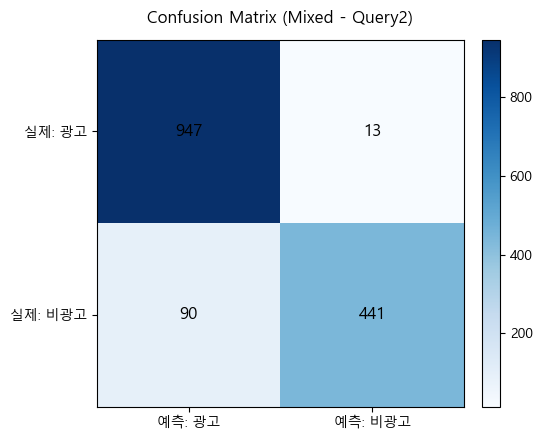

In [28]:
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

label_map_bin_q2 = {"광고성 글": 0, "비광고성 글": 1}

df_bin_mix_q2 = df_result_q2[df_result_q2["분류"].isin(label_map_bin_q2.keys())].copy()
df_bin_mix_q2["y"] = df_bin_mix_q2["분류"].map(label_map_bin_q2)

print("라벨 분포 (0=광고, 1=비광고):")
print(df_bin_mix_q2["y"].value_counts())

text_col_q2 = "text_clean"

if text_col_q2 not in df_bin_mix_q2.columns:
    raise ValueError(f"'{text_col_q2}' 컬럼이 없습니다. 전처리 셀을 먼저 실행해주세요.")

X_text_mix_q2 = df_bin_mix_q2[text_col_q2].fillna("").tolist()
y_true_q2 = df_bin_mix_q2["y"].values

if "tfidf_mix" not in globals() or "logit_mix" not in globals():
    raise RuntimeError("tfidf_mix / logit_mix (Mixed 모델)가 없습니다. Mixed 학습 셀을 먼저 실행하세요.")

X_mix_q2 = tfidf_mix.transform(X_text_mix_q2)
proba_mix_q2 = logit_mix.predict_proba(X_mix_q2)[:, 1]
threshold_mix_q2 = 0.5
y_pred_mix_q2 = (proba_mix_q2 >= threshold_mix_q2).astype(int)

print("=== Mixed 모델 평가 (쿼리 변경) ===")
print(f"threshold_mix_q2 = {threshold_mix_q2}\n")

print("[Classification Report]")
print(classification_report(y_true_q2, y_pred_mix_q2, target_names=["광고", "비광고"]))

cm_mix_q2 = confusion_matrix(y_true_q2, y_pred_mix_q2)
cm_mix_df_q2 = pd.DataFrame(
    cm_mix_q2,
    index=["실제: 광고", "실제: 비광고"],
    columns=["예측: 광고", "예측: 비광고"],
)


# ---- Confusion Matrix(시각화) ----
plt.figure(figsize=(5.5, 4.5))
plt.imshow(cm_mix_df_q2.values, cmap="Blues")
plt.title("Confusion Matrix (Mixed - Query2)", pad=12)

plt.xticks(np.arange(cm_mix_df_q2.shape[1]), cm_mix_df_q2.columns, rotation=0)
plt.yticks(np.arange(cm_mix_df_q2.shape[0]), cm_mix_df_q2.index)

# 셀 안 숫자 표시
for i in range(cm_mix_df_q2.shape[0]):
    for j in range(cm_mix_df_q2.shape[1]):
        plt.text(j, i, cm_mix_df_q2.values[i, j],
                 ha="center", va="center", fontsize=12)

plt.colorbar(fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


---
## 최종결과
비광고 점수 높은 순서대로 출력

In [29]:
from IPython.display import HTML

# 1) 하이퍼파라미터: 얼마나 "안전하게" 비광고만 보여줄지
THRESHOLD_Q2 = 0.8   # 비광고일 확률이 0.8 이상인 글만 보여주기
TOP_N_Q2     = 50    # 상위 N개만 출력

text_col_q2 = "text_clean"  # 노트북에서 사용하던 텍스트 컬럼

# 2) 전체 df_result에 대해 Mixed 모델 비광고 확률 계산
X_all_mix_q2 = tfidf_mix.transform(df_result_q2[text_col_q2].tolist())
proba_all_mix_q2 = logit_mix.predict_proba(X_all_mix_q2)[:, 1]   # 클래스 1 = 비광고

df_result_q2["proba_nonad_mix_q2"] = proba_all_mix_q2
df_result_q2["pred_nonad_mix_q2"] = (df_result_q2["proba_nonad_mix_q2"] >= THRESHOLD_Q2).astype(int)

# 3) 비광고로 예측된 글들만 추출하고, "점수" 높은 순으로 정렬
df_nonad_q2 = df_result_q2[df_result_q2["pred_nonad_mix_q2"] == 1].copy()
df_nonad_q2 = df_nonad_q2.sort_values("점수", ascending=False)


print(f"비광고로 예측된 글 수 (threshold={THRESHOLD_Q2}):", len(df_nonad_q2))

# 4) Jupyter에서 클릭 가능한 링크로 보여주기
def make_clickable(url):
    return f'<a href="{url}" target="_blank">열기</a>'

df_show_q2 = df_nonad_q2.head(TOP_N_Q2).copy()
df_show_q2["링크"] = df_show_q2["링크"].apply(make_clickable)

cols = ["검색어", "제목", "요약", "분류", "점수", "proba_nonad_mix_q2", "링크"]

HTML(df_show_q2[cols].to_html(escape=False, index=False))


비광고로 예측된 글 수 (threshold=0.8): 313


검색어,제목,요약,분류,점수,proba_nonad_mix_q2,링크
립밤 후기,립플럼핑 선키스드 플럼프 립밤 실사용후기 (내돈내산),나쁘지않았어요 립밤대신 사용할만하지만 립펌플링효과를 기대하고 사용하긴 많이 부족하네요 재구매 의사는 ?? 글쎄요??? 립플럼핑 선키스드 플럼프 립밤 실사용후기 (내돈내산) 이였습니다 #립플럼핑 #플럼프,비광고성 글,13.0,0.993164,열기
립밤 후기,인트로버트 글로우 플레이 텐더토크 립밤 내돈내산 실사용 후기,맥 글로우 플레이 텐더토크 립밤 인트로버트 안녕하세요 뷰티블로거 개살구입니다 :) 오늘은 맥mac 글로우 플레이 텐더토크 립 밤 인트로버트 내돈내산 실사용후기 및 입술발색 보여드리려고해요~! 맥 립밤은...,비광고성 글,13.0,0.971686,열기
립밤 추천,올리브영 립밤 추천 내돈내산 핑크립밤 쿨톤 컬러립밤 3가지...,올영세일 #올영내돈내산 #내돈내산립밤비교 #내돈내산리뷰 #올리브영 #올리브영립밤 #올리브영립밤추천 #올리브영립밤1위 #올리브영립밤순위 #올리브영립밤보습 #올리브영립밤보습추천 #컬러립밤 #컬러립밤추천,비광고성 글,12.0,0.883942,열기
립밤 후기,[후기] 립밤없이 못 사는 사람의 립밤 추천 #전부내돈내산...,요거 추천합니다 이상 자칭 립밤 귀신 립밤없이 단 1초도 못 사는 립밤인간의 찐 후기 끝 #립밤후기 #립밤추천 #내돈내산립밤후기 #내돈내산립밤후기추천 #내돈내산립밤추천템 #립밤추천템 #가성비좋은립밤...,비광고성 글,12.0,0.940907,열기
립밤 후기,프라다 립밤 내돈내산 실사용 후기 명품 립밤✨,프라다 립밤 실사용 후기 | 촉촉+고급스러움 가득한 명품 립밤✨ 요즘 명품 뷰티 라인들이 정말 핫하죠?... 립밤추천제품 #립밤사용기 #립밤비교 #립밤후기 #립밤발색 #립밤지속력 #명품코스메틱 #립밤컬러,비광고성 글,11.5,0.941602,열기
립밤 후기,"닥터벨머 립밤, 촉촉함과 생기를 동시에! 내돈내산 솔직 후기",오늘은 제가 직접 구매하고 사용해본 닥터벨머 립밤 솔직 후기를 들려드릴게요. 왜 닥터벨머 립밤을... 립밤을 지금 바로 구매하여 촉촉하고 건강한 입술을 경험해보세요! 오늘 닥터벨머립밤 후기를통해...,비광고성 글,11.5,0.966762,열기
립밤 후기,립밤추천 맥 텐더토크 립밤 프리티미업 솔직후기,내돈내산 후기라고 적었지만 정확하게 따지면 내돈내산은 아니고 작년 생일 때 선물 받은 립밤을... 생일에 선물주거나 아님 선물 받으면 잘 쓸 것 같지만 내돈내산은 안 할 것 같은 맥 텐더토크 립밤 후기 끝 ~!,비광고성 글,11.0,0.906023,열기
립밤 후기,세일 내돈내산 립밤추천 '립리프 스티밍 립밤 립마스크' 후기,"안녕하세요 여러분 오늘은 올리브영 립밤 추천 #립리프 립밤, 립마스크 내돈내산 솔직후기 ~ 저는... 만족하고 있는 립리프 립밤 후기 끝! #올리브영 #올리브영립밥 #립리프 #립리프내돈내산 #서이추환영 #서이추",비광고성 글,11.0,0.972897,열기
립밤 리뷰,내돈내산 히말라야 립밤 솔직 후기,"내돈내산 히말라야 립밤, 허니 글로스 립밤 리뷰 시작❤️ 히말라야 오리지널 립밤 솔직 후기 (보습력 + 꾸덕꾸덕한 립밤) 전성분 히말라야 립밤 전성분 페트롤라툼, 미네랄오일, 세레신...",비광고성 글,10.0,0.997800,열기
립밤 후기,"프라다 바나나립밤 내돈내산 후기, 발색·가격까지 솔직 정리","프라다 바나나립밤 내돈내산 후기, 이건 그냥 예술임다... 진짜 웃기죠... 립밤 사놓고 이렇게 벅차오를... 프라다립밤, 프라다바나나립밤, 립밤후기, 립밤추천, 프라다뷰티, 내돈내산립밤",비광고성 글,9.5,0.991572,열기
